# Bruun Rule Validation - Figures

Builds figures from the outputs already exported by `bruunvalidation.ipynb` (in `output/validation/`).
This notebook only reads those exported CSVs; it does not recompute anything.

## 1. Set Up Environment and Load Exported Data

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
VALIDATION_DIR = PROJECT_ROOT / "output" / "validation"
FIGURES_DIR = VALIDATION_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EQ_ORDER = ["hallin", "birk", "hallout"]
EQ_LABELS = {"hallin": "Hallermeier (inner)", "birk": "Birkemeier 1985", "hallout": "Hallermeier (outer)"}
EQ_PALETTE = dict(zip(EQ_ORDER, sns.color_palette("deep", len(EQ_ORDER))))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("VALIDATION_DIR:", VALIDATION_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: /mnt/Bruunrule_Yaxiong/code
VALIDATION_DIR: /mnt/Bruunrule_Yaxiong/code/output/validation
FIGURES_DIR: /mnt/Bruunrule_Yaxiong/code/output/validation/figures


In [16]:
rows_path = VALIDATION_DIR / "bruun_validation_rows_pre2000_to_2024.csv"
metrics_valid_path = VALIDATION_DIR / "bruun_validation_metrics_by_equation.csv"
metrics_train_path = VALIDATION_DIR / "bruun_training_metrics_by_equation.csv"

for p in [rows_path, metrics_valid_path, metrics_train_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}; run bruunvalidation.ipynb first.")

data = pd.read_csv(rows_path, low_memory=False)
metrics_valid = pd.read_csv(metrics_valid_path)
metrics_train = pd.read_csv(metrics_train_path)

data["equation"] = pd.Categorical(data["equation"], categories=EQ_ORDER, ordered=True)
metrics_valid["equation"] = pd.Categorical(metrics_valid["equation"], categories=EQ_ORDER, ordered=True)
metrics_train["equation"] = pd.Categorical(metrics_train["equation"], categories=EQ_ORDER, ordered=True)
metrics_valid = metrics_valid.sort_values("equation").reset_index(drop=True)
metrics_train = metrics_train.sort_values("equation").reset_index(drop=True)

print("Rows:", len(data))
data.head()

Rows: 540710


,Unique_ID,CD,B,L,R_bruun,Site ID,point_X,point_Y,ux1,uy1,...,n_pts_post2000,obs_train_m_used,obs_valid_m_used,pred_train_m,resid_train_m,pred_valid_m,pred_latest_x,pred_latest_y,xy_err_m,resid_valid_m
0,200409446488,16.380001,10.0,1634.662585,61.965979,5440,5.613323e+06,-4.286012e+06,-0.750271,0.66113,...,1.0,-2.618412,25.974220,-1.744675,0.873737,3.717959,1.109274e+06,4.941741e+06,22.256261,-22.256261
1,200409447515,16.380001,10.0,1634.662585,61.965979,5440,5.613332e+06,-4.286006e+06,-0.750271,0.66113,...,1.0,0.577844,24.546313,-1.744675,-2.322519,3.717959,1.109281e+06,4.941748e+06,20.828354,-20.828354
2,200409448528,16.380001,10.0,1634.662585,61.965979,5440,5.613341e+06,-4.286000e+06,-0.750271,0.66113,...,1.0,1.008877,23.112370,-1.744675,-2.753552,3.717959,1.109288e+06,4.941755e+06,19.394411,-19.394411
3,200409449534,16.380001,10.0,1634.662585,61.965979,5440,5.613349e+06,-4.285993e+06,-0.750271,0.66113,...,1.0,-0.407269,22.670049,-1.744675,-1.337406,3.717959,1.109295e+06,4.941762e+06,18.952091,-18.952091
4,200409450537,16.380001,10.0,1634.662585,61.965979,5440,5.613357e+06,-4.285986e+06,-0.750271,0.66113,...,1.0,-1.842998,22.943636,-1.744675,0.098323,3.717959,1.109302e+06,4.941770e+06,19.225678,-19.225678


## 2. Figure: Training vs Validation Error by Equation

/tmp/ipykernel_1510732/2700401061.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EQ_LABELS[e] for e in EQ_ORDER], rotation=15, ha="right")
/tmp/ipykernel_1510732/2700401061.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EQ_LABELS[e] for e in EQ_ORDER], rotation=15, ha="right")
/tmp/ipykernel_1510732/2700401061.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EQ_LABELS[e] for e in EQ_ORDER], rotation=15, ha="right")


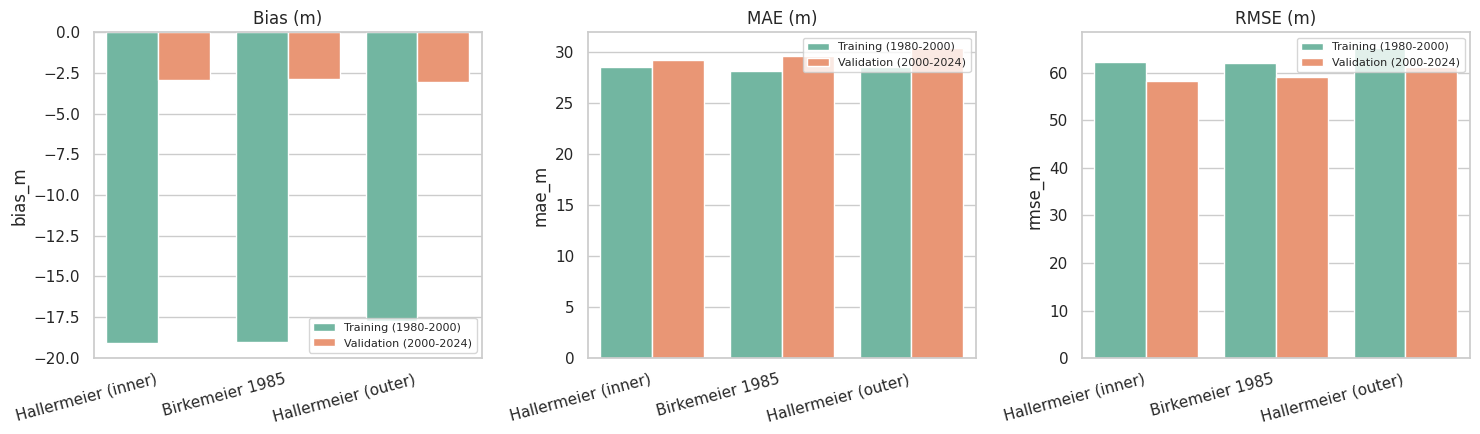

In [17]:
metrics_train_m = metrics_train.assign(period="Training (1980-2000)")
metrics_valid_m = metrics_valid.assign(period="Validation (2000-2024)")
metrics_combined = pd.concat(
    [
        metrics_train_m[["equation", "period", "bias_m", "mae_m", "rmse_m"]],
        metrics_valid_m[["equation", "period", "bias_m", "mae_m", "rmse_m"]],
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, metric, title in zip(
    axes, ["bias_m", "mae_m", "rmse_m"], ["Bias (m)", "MAE (m)", "RMSE (m)"]
):
    sns.barplot(
        data=metrics_combined, x="equation", y=metric, hue="period", ax=ax,
        order=EQ_ORDER, palette="Set2",
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_xticklabels([EQ_LABELS[e] for e in EQ_ORDER], rotation=15, ha="right")
    ax.legend(title="", fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_train_vs_validation_error.png", dpi=220)
plt.show()

## 3. Figure: Observed vs Predicted, Validation Period (Small Multiples)

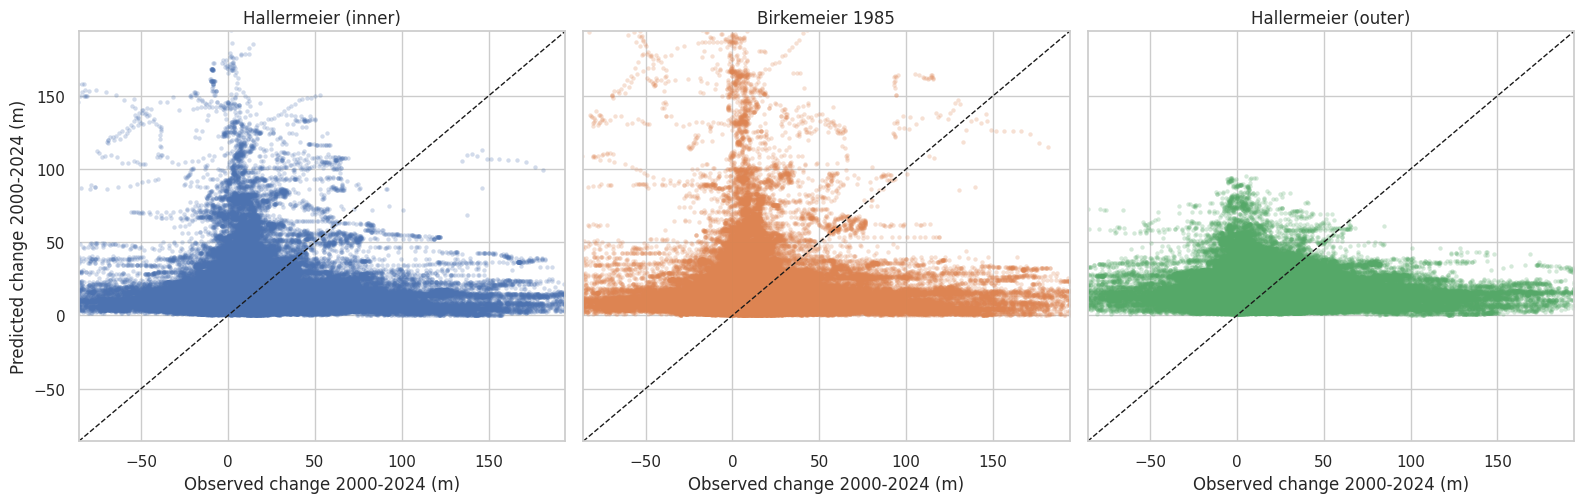

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

lo = data[["obs_valid_m_used", "pred_valid_m"]].quantile(0.01).min()
hi = data[["obs_valid_m_used", "pred_valid_m"]].quantile(0.99).max()

for ax, eq in zip(axes, EQ_ORDER):
    sub = data[data["equation"] == eq]
    sns.scatterplot(
        data=sub, x="obs_valid_m_used", y="pred_valid_m", ax=ax,
        s=10, alpha=0.25, color=EQ_PALETTE[eq], linewidth=0,
    )
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(EQ_LABELS[eq])
    ax.set_xlabel("Observed change 2000-2024 (m)")
    ax.set_ylabel("Predicted change 2000-2024 (m)" if eq == EQ_ORDER[0] else "")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_obs_vs_pred_validation.png", dpi=220)
plt.show()

## 4. Figure: Residual Distributions (Training and Validation)

/tmp/ipykernel_1510732/953220482.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EQ_LABELS[e] for e in EQ_ORDER])


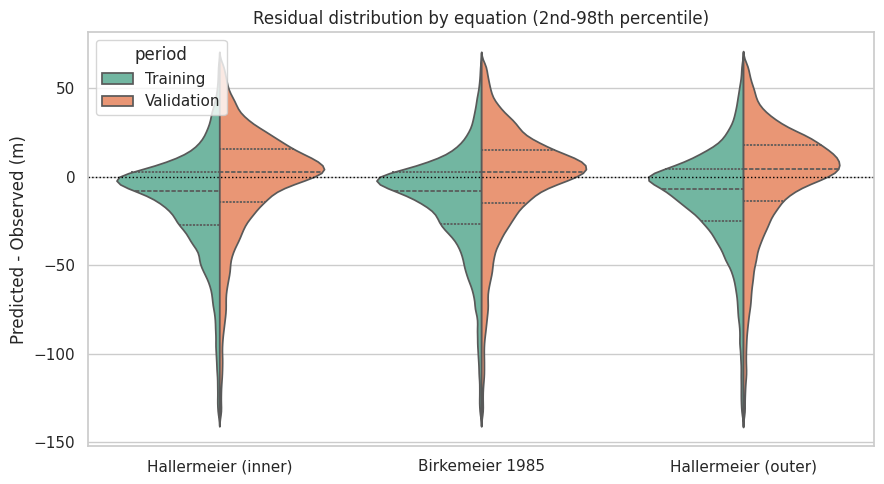

In [19]:
resid_long = pd.concat(
    [
        data[["equation", "resid_train_m"]].rename(columns={"resid_train_m": "residual_m"}).assign(period="Training"),
        data[["equation", "resid_valid_m"]].rename(columns={"resid_valid_m": "residual_m"}).assign(period="Validation"),
    ],
    ignore_index=True,
).dropna(subset=["residual_m"])

# Clip extreme outliers only for display so the violin shapes stay readable.
q_lo, q_hi = resid_long["residual_m"].quantile([0.02, 0.98])
resid_plot = resid_long[(resid_long["residual_m"] >= q_lo) & (resid_long["residual_m"] <= q_hi)]

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=resid_plot, x="equation", y="residual_m", hue="period", split=True,
    order=EQ_ORDER, ax=ax, inner="quartile", palette="Set2",
)
ax.axhline(0, color="black", linewidth=1, linestyle=":")
ax.set_xticklabels([EQ_LABELS[e] for e in EQ_ORDER])
ax.set_xlabel("")
ax.set_ylabel("Predicted - Observed (m)")
ax.set_title("Residual distribution by equation (2nd-98th percentile)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_residual_distributions.png", dpi=220)
plt.show()

## 5. Figure: Spatial Map of Validation Residuals (Best Equation)

Best-performing equation (validation RMSE): hallin


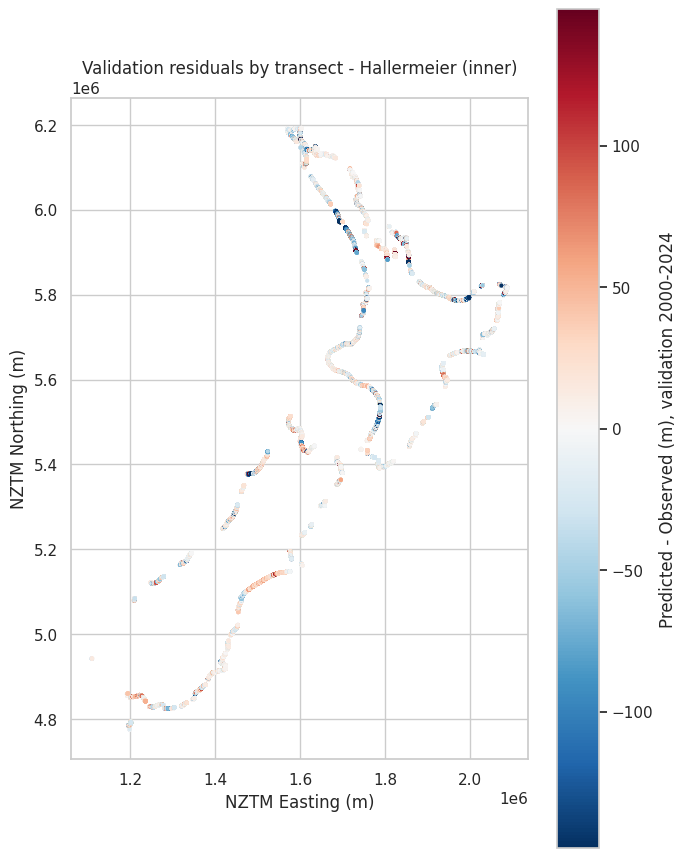

In [20]:
best_eq = metrics_valid.iloc[0]["equation"]
print("Best-performing equation (validation RMSE):", best_eq)

map_df = data[data["equation"] == best_eq].dropna(subset=["first_x", "first_y", "resid_valid_m"]).copy()
gdf = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.points_from_xy(map_df["first_x"], map_df["first_y"]),
    crs="EPSG:2193",
)

vmax = gdf["resid_valid_m"].abs().quantile(0.98)

fig, ax = plt.subplots(figsize=(7, 9))
gdf.plot(
    column="resid_valid_m", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
    markersize=4, legend=True, ax=ax,
    legend_kwds={"label": "Predicted - Observed (m), validation 2000-2024"},
)
ax.set_title(f"Validation residuals by transect - {EQ_LABELS[best_eq]}")
ax.set_xlabel("NZTM Easting (m)")
ax.set_ylabel("NZTM Northing (m)")
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig4_residual_map_best_equation.png", dpi=220)
plt.show()

## 6. Figure: Pre-2000 vs Post-2000 Observed Erosion Rate (Acceleration Check)

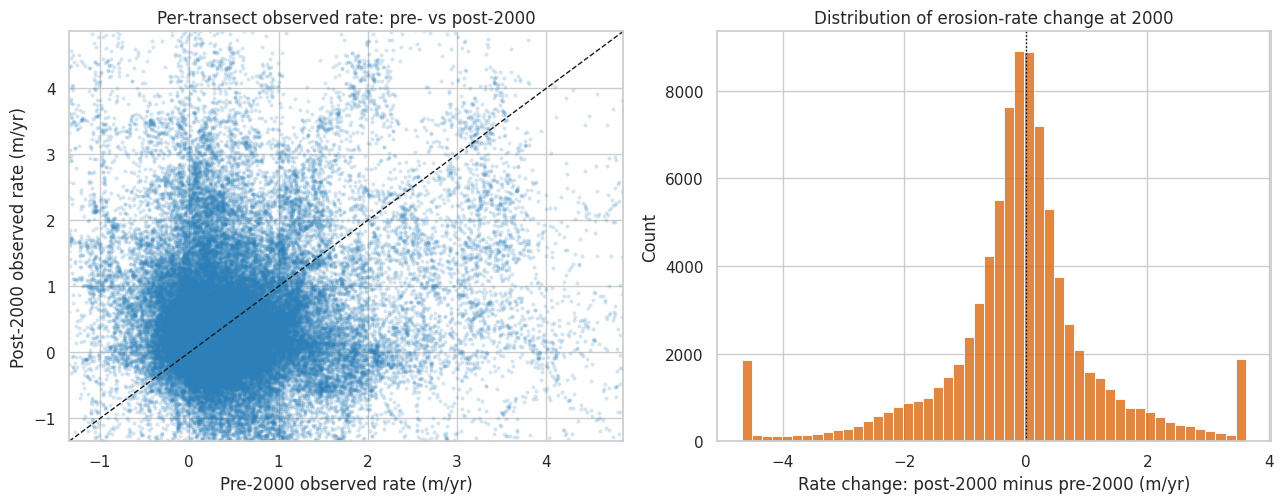

In [21]:
rates = data.drop_duplicates(subset="Unique_ID")[
    ["Unique_ID", "obs_rate_pre2000_m_per_yr", "obs_rate_post2000_m_per_yr"]
].dropna()
rates["rate_change_m_per_yr"] = rates["obs_rate_post2000_m_per_yr"] - rates["obs_rate_pre2000_m_per_yr"]

lo_r, hi_r = rates[["obs_rate_pre2000_m_per_yr", "obs_rate_post2000_m_per_yr"]].quantile([0.01, 0.99]).to_numpy().flatten()[[0, -1]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.scatterplot(
    data=rates, x="obs_rate_pre2000_m_per_yr", y="obs_rate_post2000_m_per_yr",
    ax=axes[0], s=8, alpha=0.2, color="#2C7FB8", linewidth=0,
)
axes[0].plot([lo_r, hi_r], [lo_r, hi_r], "k--", linewidth=1)
axes[0].set_xlim(lo_r, hi_r)
axes[0].set_ylim(lo_r, hi_r)
axes[0].set_xlabel("Pre-2000 observed rate (m/yr)")
axes[0].set_ylabel("Post-2000 observed rate (m/yr)")
axes[0].set_title("Per-transect observed rate: pre- vs post-2000")

sns.histplot(rates["rate_change_m_per_yr"].clip(*rates["rate_change_m_per_yr"].quantile([0.02, 0.98])), bins=50, ax=axes[1], color="#D95F02")
axes[1].axvline(0, color="black", linewidth=1, linestyle=":")
axes[1].set_xlabel("Rate change: post-2000 minus pre-2000 (m/yr)")
axes[1].set_title("Distribution of erosion-rate change at 2000")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig5_rate_change_pre_post_2000.png", dpi=220)
plt.show()

## 7. Where Do Predictions Best Match Observations? Parameter Correlates

Pull in beach slope (`tanbeta`) and wave height (`Hs_12h_y`) per transect/equation from the
raw pipeline outputs (not exported by `bruunvalidation.ipynb`), then look for common
geometry/wave parameters (elevation `B`, slope, `CD`, transect length `L`, `Hs`) in the areas
where the Bruun prediction is closest to the real observed trend.

In [22]:
# Raw pipeline outputs live under /mnt/Bruunrule_Yaxiong (one level above this repo's "code" folder).
PIPELINE_ROOT = PROJECT_ROOT.parent
BRUUNRULE_DIR = PIPELINE_ROOT / "output" / "bruunrule"
WAVEDATASUM_DIR = PIPELINE_ROOT / "input" / "wavedata" / "WGselected"

from scipy.spatial import cKDTree
from pyproj import Transformer

WAVE_MATCH_TOL_M = 50  # matched wave-gauge points should coincide almost exactly after reprojection

param_frames = []
for eq in EQ_ORDER:
    bruunrule_fp = BRUUNRULE_DIR / f"bruunrule_{eq}.gpkg"
    wavesum_fp = WAVEDATASUM_DIR / f"wavedatasum_merged_1979-01-01_2024-01-01_{eq}.gpkg"
    if not bruunrule_fp.exists() or not wavesum_fp.exists():
        print(f"WARNING: skipping {eq}, missing {bruunrule_fp if not bruunrule_fp.exists() else wavesum_fp}")
        continue

    geom_cols = ["Unique_ID", "tanbeta", "beta_degree", "CD", "B", "L", "wave_X", "wave_Y"]
    br = gpd.read_file(bruunrule_fp, columns=geom_cols)
    br["Unique_ID"] = pd.to_numeric(br["Unique_ID"], errors="coerce").astype("Int64")

    wave_sum = gpd.read_file(wavesum_fp, columns=["seapoint", "Hs_12h_y", "Hs_mean", "Ts_mean"])

    # br is in the bruunrule pipeline CRS (EPSG:3994); wave_sum is EPSG:2193 - reproject
    # the transect-side wave_X/wave_Y to EPSG:2193 and nearest-match to the wave summary points.
    to_2193 = Transformer.from_crs(br.crs, wave_sum.crs, always_xy=True)
    wx, wy = to_2193.transform(br["wave_X"].to_numpy(), br["wave_Y"].to_numpy())

    wave_xy = np.column_stack([wave_sum.geometry.x.to_numpy(), wave_sum.geometry.y.to_numpy()])
    tree = cKDTree(wave_xy)
    dist, idx = tree.query(np.column_stack([wx, wy]), k=1)

    matched = wave_sum.iloc[idx][["Hs_12h_y", "Hs_mean", "Ts_mean"]].reset_index(drop=True)
    matched.loc[dist > WAVE_MATCH_TOL_M, :] = np.nan

    br = br.drop(columns="geometry")
    br[["Hs_12h_y", "Hs_mean", "Ts_mean"]] = matched.to_numpy()
    br["equation"] = eq
    param_frames.append(br[["Unique_ID", "equation", "tanbeta", "beta_degree", "Hs_12h_y", "Hs_mean", "Ts_mean"]])

params = pd.concat(param_frames, ignore_index=True) if param_frames else pd.DataFrame()
if not params.empty:
    print("Wave-gauge match success rate:", params["Hs_12h_y"].notna().mean().round(3))
    data = data.merge(params, on=["Unique_ID", "equation"], how="left")
params.head()

Wave-gauge match success rate: 1.0


,Unique_ID,equation,tanbeta,beta_degree,Hs_12h_y,Hs_mean,Ts_mean
0,200409446488,hallin,0.016138,0.924553,8.59,3.505231,8.625437
1,200409447515,hallin,0.016138,0.924553,8.59,3.505231,8.625437
2,200409448528,hallin,0.016138,0.924553,8.59,3.505231,8.625437
3,200409449534,hallin,0.016138,0.924553,8.59,3.505231,8.625437
4,200409450537,hallin,0.016138,0.924553,8.59,3.505231,8.625437


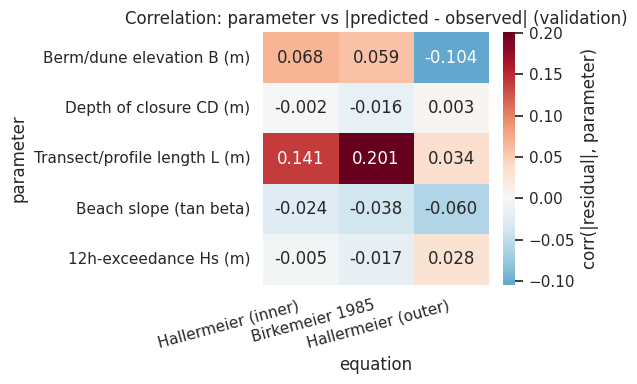

equation,hallin,birk,hallout
parameter,,,
B,0.068381,0.058689,-0.104258
CD,-0.002312,-0.015778,0.003302
L,0.140761,0.200790,0.033510
tanbeta,-0.024071,-0.037830,-0.059650
Hs_12h_y,-0.004834,-0.017311,0.028369


In [23]:
PARAMS = ["B", "CD", "L", "tanbeta", "Hs_12h_y"]
PARAM_LABELS = {
    "B": "Berm/dune elevation B (m)",
    "CD": "Depth of closure CD (m)",
    "L": "Transect/profile length L (m)",
    "tanbeta": "Beach slope (tan beta)",
    "Hs_12h_y": "12h-exceedance Hs (m)",
}

data["abs_resid_valid_m"] = data["resid_valid_m"].abs()

# Correlation of match quality (smaller |residual| = better match) with each parameter, per equation.
corr_rows = []
for eq in EQ_ORDER:
    sub = data[data["equation"] == eq]
    for p in PARAMS:
        d = sub[[p, "abs_resid_valid_m"]].dropna()
        corr = d[p].corr(d["abs_resid_valid_m"]) if len(d) > 2 else np.nan
        corr_rows.append({"equation": eq, "parameter": p, "n": len(d), "corr_with_abs_resid": corr})

corr_df = pd.DataFrame(corr_rows)
corr_pivot = corr_df.pivot(index="parameter", columns="equation", values="corr_with_abs_resid").loc[PARAMS, EQ_ORDER]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "corr(|residual|, parameter)"})
ax.set_yticklabels([PARAM_LABELS[p] for p in PARAMS], rotation=0)
ax.set_xticklabels([EQ_LABELS[e] for e in EQ_ORDER], rotation=15, ha="right")
ax.set_title("Correlation: parameter vs |predicted - observed| (validation)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig6_param_vs_abs_residual_corr.png", dpi=220)
plt.show()
corr_pivot

/tmp/ipykernel_1510732/2058983245.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1510732/2058983245.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Good", "Poor"])
/tmp/ipykernel_1510732/2058983245.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1510732/2058983245.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Good", "Poor"])
/tmp/ipykernel_1510732/2058983245.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is dep

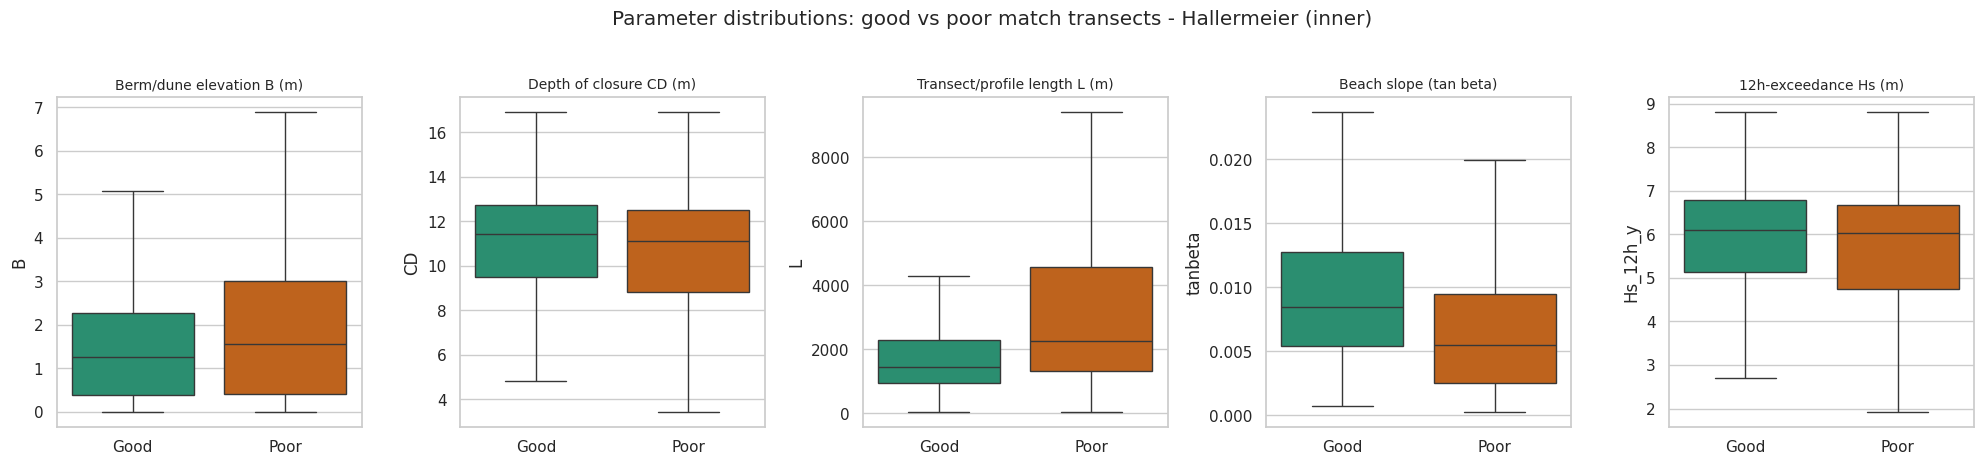

,B,CD,L,tanbeta,Hs_12h_y
match_group,,,,,
Good match (bottom 25% |resid|),1.254,11.423196,1461.957085,0.008460,6.086
Poor match (top 25% |resid|),1.562,11.126745,2249.048985,0.005513,6.036


In [24]:
# Split transects (for the best-performing equation) into "good match" (lowest-quartile
# |residual|) vs "poor match" (highest-quartile |residual|) and compare parameter
# distributions between the two groups.
best_sub = data[data["equation"] == best_eq].dropna(subset=["abs_resid_valid_m"]).copy()
q_good, q_poor = best_sub["abs_resid_valid_m"].quantile([0.25, 0.75])
best_sub["match_group"] = np.select(
    [best_sub["abs_resid_valid_m"] <= q_good, best_sub["abs_resid_valid_m"] >= q_poor],
    ["Good match (bottom 25% |resid|)", "Poor match (top 25% |resid|)"],
    default="Middle 50%",
)
group_sub = best_sub[best_sub["match_group"] != "Middle 50%"]

fig, axes = plt.subplots(1, len(PARAMS), figsize=(4 * len(PARAMS), 4.5))
for ax, p in zip(axes, PARAMS):
    sns.boxplot(
        data=group_sub, x="match_group", y=p, ax=ax,
        order=["Good match (bottom 25% |resid|)", "Poor match (top 25% |resid|)"],
        palette=["#1B9E77", "#D95F02"], showfliers=False,
    )
    ax.set_title(PARAM_LABELS[p], fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(["Good", "Poor"])

fig.suptitle(f"Parameter distributions: good vs poor match transects - {EQ_LABELS[best_eq]}", y=1.03)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig7_good_vs_poor_match_params.png", dpi=220, bbox_inches="tight")
plt.show()

group_sub.groupby("match_group")[PARAMS].median()

In [ ]:
## 8. Spatial Pattern: Match Quality and Parameters Side by Side

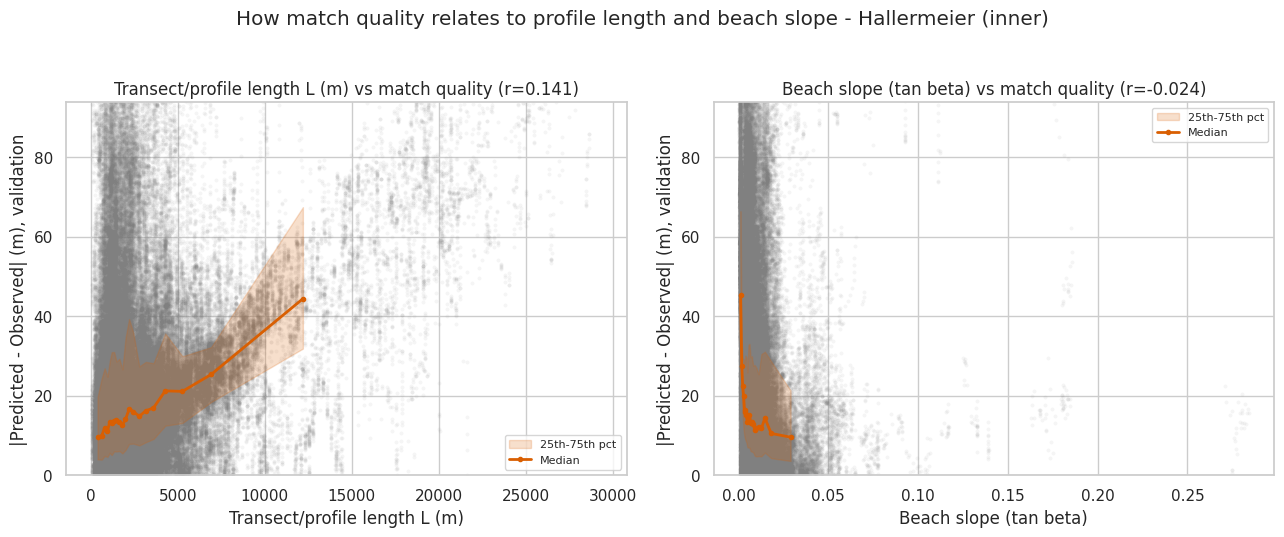

In [25]:
# Direct relationship (binned trend over raw scatter) between match quality and each
# parameter for the best equation - clearer than cross-referencing separate spatial maps.
best_rel = data[data["equation"] == best_eq].dropna(subset=["abs_resid_valid_m", "L", "tanbeta"]).copy()

def binned_trend(ax, x, y, n_bins=20, color="#D95F02"):
    bins = pd.qcut(x, q=n_bins, duplicates="drop")
    grp = y.groupby(bins, observed=True)
    x_mid = x.groupby(bins, observed=True).median()
    med = grp.median()
    q25 = grp.quantile(0.25)
    q75 = grp.quantile(0.75)
    order = np.argsort(x_mid.to_numpy())
    ax.fill_between(x_mid.to_numpy()[order], q25.to_numpy()[order], q75.to_numpy()[order], color=color, alpha=0.2, label="25th-75th pct")
    ax.plot(x_mid.to_numpy()[order], med.to_numpy()[order], color=color, marker="o", markersize=3, linewidth=2, label="Median")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for ax, param in zip(axes, ["L", "tanbeta"]):
    sns.scatterplot(data=best_rel, x=param, y="abs_resid_valid_m", ax=ax, s=8, alpha=0.08, color="grey", linewidth=0)
    binned_trend(ax, best_rel[param], best_rel["abs_resid_valid_m"])
    r = best_rel[param].corr(best_rel["abs_resid_valid_m"])
    ax.set_xlabel(PARAM_LABELS[param])
    ax.set_ylabel("|Predicted - Observed| (m), validation")
    ax.set_title(f"{PARAM_LABELS[param]} vs match quality (r={r:.3f})")
    ax.set_ylim(0, best_rel["abs_resid_valid_m"].quantile(0.95))
    ax.legend(fontsize=8)

fig.suptitle(f"How match quality relates to profile length and beach slope - {EQ_LABELS[best_eq]}", y=1.03)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig8_match_quality_vs_L_slope.png", dpi=220, bbox_inches="tight")
plt.show()

## 9. Distribution of Observed vs Predicted Shoreline Change

Full min/max/median/mean/std summary for observed and predicted 2000-2024 change, and the
residual (predicted - observed), per equation.

In [26]:
def dist_stats(s):
    return pd.Series({
        "min": s.min(), "p25": s.quantile(0.25), "median": s.median(),
        "mean": s.mean(), "p75": s.quantile(0.75), "max": s.max(), "std": s.std(),
    })

dist_rows = []
for eq in EQ_ORDER:
    sub = data[data["equation"] == eq]
    for label, col in [("Observed", "obs_valid_m_used"), ("Predicted", "pred_valid_m"), ("Residual (pred-obs)", "resid_valid_m")]:
        stats = dist_stats(sub[col].dropna())
        dist_rows.append({"equation": EQ_LABELS[eq], "quantity": label, **stats.to_dict()})

dist_df = pd.DataFrame(dist_rows).set_index(["equation", "quantity"])
dist_df.round(2)

min    p25  median   mean    p75  \
equation            quantity                                                    
Hallermeier (inner) Observed            -1167.74  -0.93    7.91  17.03  25.69   
                    Predicted               0.21   5.67    9.43  14.09  16.70   
                    Residual (pred-obs) -1289.68 -14.80    3.18  -2.94  17.07   
Birkemeier 1985     Observed            -1167.74  -0.94    7.82  16.80  25.36   
                    Predicted               0.28   5.26    8.75  13.94  15.67   
                    Residual (pred-obs) -1288.90 -15.36    2.80  -2.86  16.45   
Hallermeier (outer) Observed            -1167.74  -1.11    8.09  18.22  27.82   
                    Predicted               0.45   7.11   12.37  15.13  20.52   
                    Residual (pred-obs) -1288.60 -14.67    4.66  -3.07  18.76   

                                             max    std  
equation            quantity                             
Hallermeier (inner) Observed             1294.40  55.89  
                    Predicted             219.56  15.15  
                    Residual (pred-obs)  1174.20  58.12  
Birkemeier 1985     Observed             1294.40  55.85  
                    Predicted             293.60  17.73  
                    Residual (pred-obs)  1175.48  59.08  
Hallermeier (outer) Observed             1294.40  60.02  
                    Predicted              94.97  10.86  
                    Residual (pred-obs)  1179.30  61.09

Note: `Predicted` is always positive (Bruun rule with these inputs only ever predicts
erosion/retreat, never accretion), while `Observed` ranges from large accretion to large
erosion (the extremes are almost certainly inlet/estuary-mouth transects, not open-coast
Bruun-applicable behaviour).

## 10. Error Magnitude: How Many Transects Are Within X Metres?

Percent of transects with |predicted - observed| within threshold (validation, 2000-2024):


,n,within 5 m,within 10 m,within 20 m,within 50 m
equation,,,,,
Hallermeier (inner),191488,18.5,34.3,57.7,85.9
Birkemeier 1985,190483,18.4,34.7,57.8,85.7
Hallermeier (outer),154942,16.6,31.3,55.5,85.6


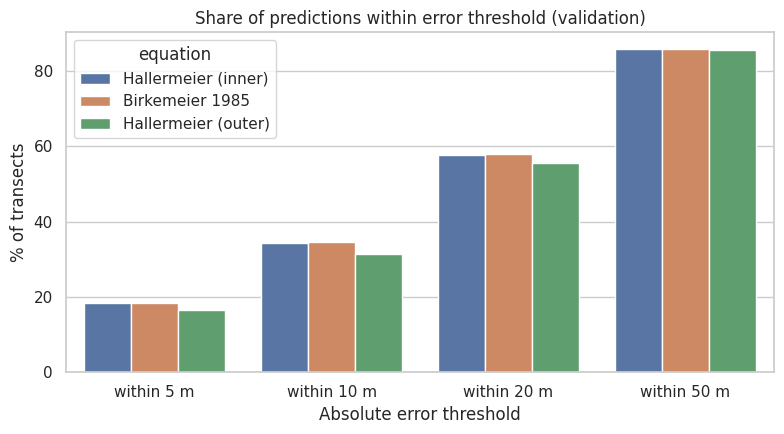

In [27]:
THRESHOLDS_M = [5, 10, 20, 50]

bucket_rows = []
for eq in EQ_ORDER:
    abs_resid = data.loc[data["equation"] == eq, "abs_resid_valid_m"].dropna()
    row = {"equation": EQ_LABELS[eq], "n": len(abs_resid)}
    for t in THRESHOLDS_M:
        row[f"within {t} m"] = (abs_resid <= t).mean() * 100
    bucket_rows.append(row)

bucket_df = pd.DataFrame(bucket_rows).set_index("equation")
print("Percent of transects with |predicted - observed| within threshold (validation, 2000-2024):")
display(bucket_df.round(1))

bucket_long = bucket_df.drop(columns="n").reset_index().melt(id_vars="equation", var_name="threshold", value_name="pct")
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=bucket_long, x="threshold", y="pct", hue="equation", ax=ax, palette=list(EQ_PALETTE.values()))
ax.set_ylabel("% of transects")
ax.set_xlabel("Absolute error threshold")
ax.set_title("Share of predictions within error threshold (validation)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig9_error_threshold_share.png", dpi=220)
plt.show()

In [28]:
# Signed breakdown: over-predicting vs under-predicting erosion, and by how much.
sign_rows = []
for eq in EQ_ORDER:
    resid = data.loc[data["equation"] == eq, "resid_valid_m"].dropna()
    row = {
        "equation": EQ_LABELS[eq],
        "% over-predicting erosion": (resid > 0).mean() * 100,
        "% under-predicting erosion": (resid < 0).mean() * 100,
        "% over-predicting by <5m": ((resid > 0) & (resid <= 5)).mean() * 100,
        "% over-predicting by 5-20m": ((resid > 5) & (resid <= 20)).mean() * 100,
        "% over-predicting by >20m": (resid > 20).mean() * 100,
    }
    sign_rows.append(row)

sign_df = pd.DataFrame(sign_rows).set_index("equation")
print("Direction and size of prediction error (validation, 2000-2024):")
sign_df.round(1)

Direction and size of prediction error (validation, 2000-2024):


,% over-predicting erosion,% under-predicting erosion,% over-predicting by <5m,% over-predicting by 5-20m,% over-predicting by >20m
equation,,,,,
Hallermeier (inner),56.5,43.5,10.3,24.8,21.3
Birkemeier 1985,55.6,44.4,10.2,24.6,20.7
Hallermeier (outer),58.6,41.4,9.3,26.1,23.2


## 11. Which Regions Get the Best/Worst Predictions?

Transects matched to a region: 1.0
Regional match quality for Hallermeier (inner) (validation, sorted best->worst):


,n,median_abs_resid,mean_abs_resid
Region,,,
Wellington,10368,7.9,13.5
Nelson,1161,7.9,14.0
Marlborough,3750,9.7,18.5
Taranaki,15473,10.4,14.5
Otago,14083,11.2,17.4
Gisborne,7623,13.0,24.0
HawkesBay,11731,14.6,21.7
Southland,10007,14.9,21.7
BayOfPlenty,12820,16.2,34.4


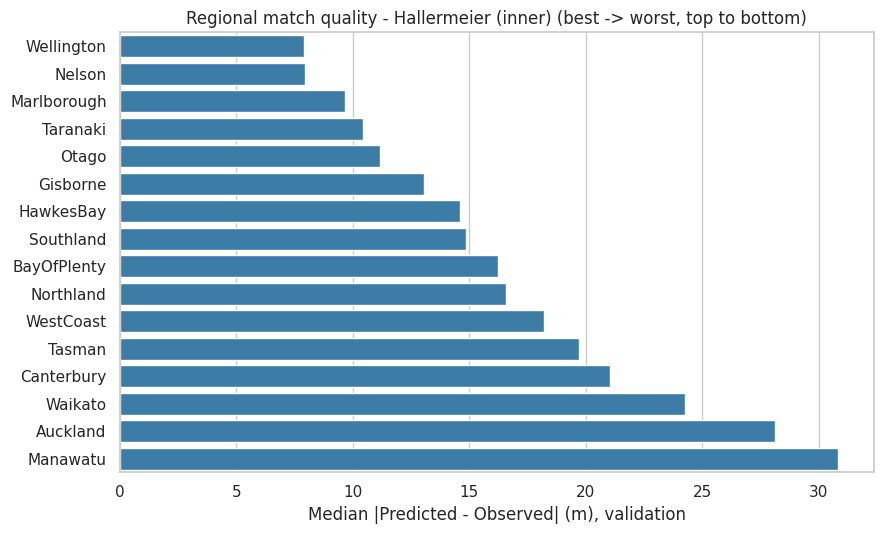

In [29]:
# NZCCD Region is per-transect metadata, not exported by bruunvalidation.ipynb - pull it
# directly from the raw shoreline points file and merge in by Unique_ID.
region_map = pd.read_csv(
    PROJECT_ROOT / "slpoints_rates.csv.gz", usecols=["Unique_ID", "Region"], low_memory=False
).drop_duplicates(subset="Unique_ID")
region_map["Unique_ID"] = pd.to_numeric(region_map["Unique_ID"], errors="coerce")
data = data.merge(region_map, on="Unique_ID", how="left")
print("Transects matched to a region:", data["Region"].notna().mean().round(3))

region_stats = (
    data[data["equation"] == best_eq]
    .groupby("Region")["abs_resid_valid_m"]
    .agg(n="size", median_abs_resid="median", mean_abs_resid="mean")
    .sort_values("median_abs_resid")
)
print(f"Regional match quality for {EQ_LABELS[best_eq]} (validation, sorted best->worst):")
display(region_stats.round(1))

fig, ax = plt.subplots(figsize=(9, 5.5))
order = region_stats.index.tolist()
sns.barplot(
    data=data[data["equation"] == best_eq], y="Region", x="abs_resid_valid_m",
    order=order, ax=ax, color="#2C7FB8", estimator=np.median, errorbar=None,
)
ax.set_xlabel("Median |Predicted - Observed| (m), validation")
ax.set_ylabel("")
ax.set_title(f"Regional match quality - {EQ_LABELS[best_eq]} (best -> worst, top to bottom)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig10_region_match_quality.png", dpi=220)
plt.show()